In [1]:
# after resizing image and sacling annotations
# check the correctness

import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import glob
import json
import os
import sys

sys.path.append("../../../../donut/src/test/")
from common.config import cfg

In [2]:
target_size=(cfg.image_width,cfg.image_height)

target_size

(640, 640)

In [3]:
# list all image paths
image_dir = "../../../data/image_resize/images/"
image_files = glob.glob(image_dir + "*")
print(len(image_files))
print(image_files[:5])

60575
['../../../data/image_resize/images/45df1fe3293b.jpg', '../../../data/image_resize/images/b2ab3b743d4e.jpg', '../../../data/image_resize/images/51d3b1a6baf3.jpg', '../../../data/image_resize/images/a9e9ce9277c1.jpg', '../../../data/image_resize/images/7f1f545fe081.jpg']


In [4]:
# list all annotation files paths

annotations_dir="../../../data/image_resize/annotations/"
annotations_files=glob.glob(annotations_dir+"*")
print(len(annotations_files))
print(annotations_files[:5])

60575
['../../../data/image_resize/annotations/e91e28111e86.json', '../../../data/image_resize/annotations/75c0449f6917.json', '../../../data/image_resize/annotations/66dd2a250237.json', '../../../data/image_resize/annotations/58595c30beab.json', '../../../data/image_resize/annotations/497a547454d7.json']


In [5]:
# line image
search_string = "0a0a78fc8d65"
matched_image_path = [file for file in image_files if search_string in file]

print(matched_image_path)

# corresponding annotation file path
matched_annotation_path = [file for file in annotations_files if search_string in file]

print(matched_annotation_path)

['../../../data/image_resize/images/0a0a78fc8d65.jpg']
['../../../data/image_resize/annotations/0a0a78fc8d65.json']


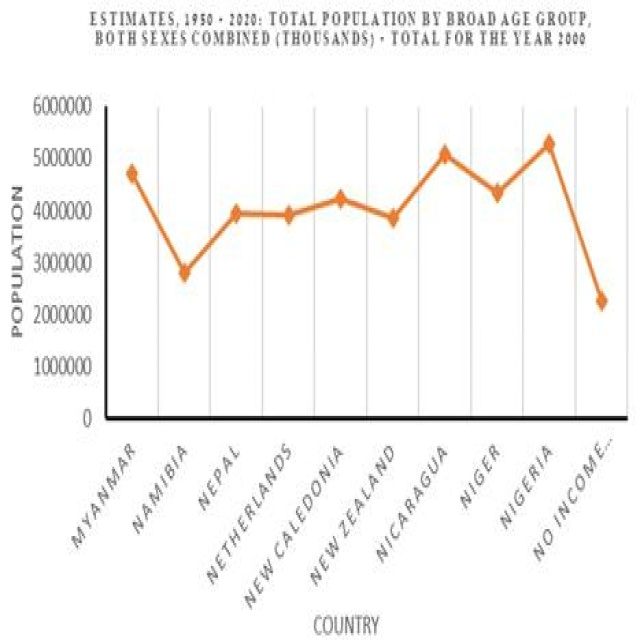

In [6]:
Image.open(fp=matched_image_path[0])

In [8]:
print(Image.open(fp=matched_image_path[0]).size)

(640, 640)


In [9]:
def image_markable(annotation_path: str, image_path: str) -> np.array:
    '''
    Mark all the available information in the annotation.json on the corresponding image file.

    Params:
        annotation_path: the path of annotation file
        image_path: the path of the image file

    Return:
        numpy.ndarray (image with annotations)
    '''
    with open(annotation_path, "r") as f:
        annotation = json.load(f)

    # load image
    image = cv2.imread(image_path)
    if image is None:
        print(f"❌ Error: Unable to load image at {image_path}")
        return None

    print(f"✅ Image loaded: {image.shape}")

    # missing elements in annotation file
    missing_elements = []

    # ----------------------  mark main body of the image (plot-bb) ----------------------
    plot_bb = annotation.get("plot-bb")
    if plot_bb:
        # get the vertex to determine the boundary
        x0, y0, width, height = plot_bb["x0"], plot_bb["y0"], plot_bb["width"], plot_bb["height"]
        cv2.rectangle(image, (x0, y0), (x0 + width, y0 + height), (255, 0, 0), 2)
    else:
        missing_elements.append("plot-bb")

    # ----------------------  mark tick location on x or y axes (ticks) ----------------------
    # use green dot to represent
    if "axes" in annotation:
        for axis in ["x-axis", "y-axis"]:
            if axis in annotation["axes"]:
                for tick in annotation["axes"][axis].get("ticks", []):
                    tick_x, tick_y = tick["tick_pt"]["x"], tick["tick_pt"]["y"]
                    cv2.circle(image, (tick_x, tick_y), 5, (0, 255, 0), -1)
            else:
                missing_elements.append(f"{axis} ticks")
    else:
        missing_elements.append("axes")

    # ----------------------  mark the points location on line graph (data-series) ----------------------
    if "visual-elements" in annotation:
        elements = annotation["visual-elements"]

        # `lines` 
        # red dot
        if "lines" in elements and elements["lines"]:
            for line in elements["lines"]:
                for data_point in line:
                    x, y = int(data_point["x"]), int(data_point["y"])
                    cv2.circle(image, (x, y), 7, (0, 0, 255), -1) 

        # `scatter points` 
        # light blue
        if "scatter points" in elements and elements["scatter points"]:
            for scatter in elements["scatter points"]:
                for point in scatter:
                    x, y = int(point["x"]), int(point["y"])
                    cv2.circle(image, (x, y), 6, (255, 165, 0), -1) 

        # `bars`
        # light yellow
        if "bars" in elements and elements["bars"]:
            for bar in elements["bars"]:
                x0, y0 = int(bar["x0"]), int(bar["y0"])  
                width, height = int(bar["width"]), int(bar["height"])
                x1, y1 = x0 + width, y0 + height  
                cv2.rectangle(image, (x0, y0), (x1, y1), (0, 255, 255), -1) 

        # `boxplots`
        if "boxplots" in elements and elements["boxplots"]:
            for box in elements["boxplots"]:
                x, y = int(box["x"]), int(box["y"])
                cv2.rectangle(image, (x - 5, y - 5), (x + 5, y + 5), (255, 0, 255), 2) 

        if "dot points" in elements and elements["dot points"]:
            for dot in elements["dot points"]:
                for point in dot:
                    x, y = int(point["x"]), int(point["y"])
                    cv2.circle(image, (x, y), 6, (255, 165, 50), -1) 
    else:
        missing_elements.append("visual-elements")

    # ----------------------  `data-series` ----------------------
    if "data-series" in annotation:
        for series in annotation["data-series"]:
            x_value = series.get("x", "Unknown")
            y_value = series.get("y", "Unknown")
            # print(f"Data point: {x_value} -> {y_value}")
    else:
        missing_elements.append("data-series")

    # ---------------------- mark the text region (text) ----------------------
    # use purple frame to represent
    if "text" in annotation:
        for text_item in annotation["text"]:
            polygon = text_item.get("polygon")
            if polygon:
                x0, y0 = polygon["x0"], polygon["y0"]
                x2, y2 = polygon["x2"], polygon["y2"]
                cv2.rectangle(image, (x0, y0), (x2, y2), (200, 50, 100), 2)
            else:
                missing_elements.append(f"text id {text_item.get('id', 'unknown')} missing polygon")
    else:
        missing_elements.append("text")

    # ---------------------- 5️⃣ output missing elements ----------------------
    if missing_elements:
        print("⚠️ Missing elements in annotation:", ", ".join(set(missing_elements)))

    return image

✅ Image loaded: (640, 640, 3)


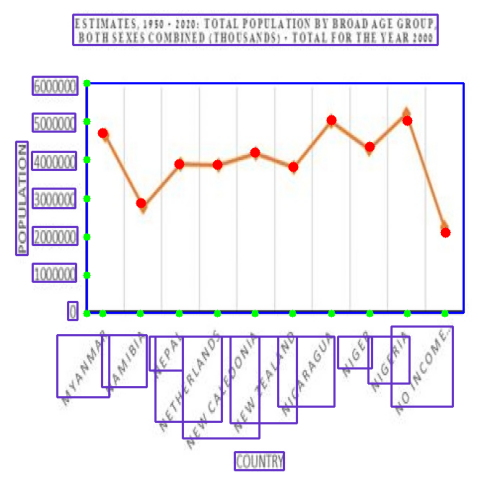

In [10]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path=matched_image_path[0])

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [11]:
# scatter plot
search_string = "0a0ef43669cd"
matched_image_path = [file for file in image_files if search_string in file]

print(matched_image_path)

# corresponding annotation file path
matched_annotation_path = [file for file in annotations_files if search_string in file]

print(matched_annotation_path)

['../../../data/image_resize/images/0a0ef43669cd.jpg']
['../../../data/image_resize/annotations/0a0ef43669cd.json']


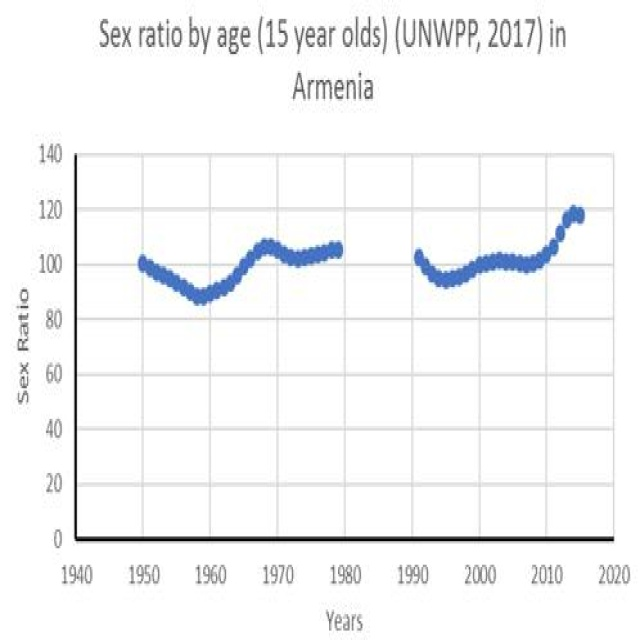

In [12]:
Image.open(fp=matched_image_path[0])

In [13]:
print(Image.open(fp=matched_image_path[0]).size)

(640, 640)


✅ Image loaded: (640, 640, 3)


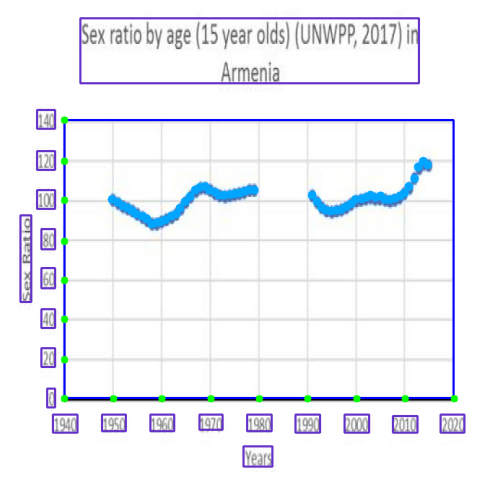

In [14]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path=matched_image_path[0])

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [15]:
# vertical bar
search_string = "0b4dac8d0a28"
matched_image_path = [file for file in image_files if search_string in file]

print(matched_image_path)

# corresponding annotation file path
matched_annotation_path = [file for file in annotations_files if search_string in file]

print(matched_annotation_path)

['../../../data/image_resize/images/0b4dac8d0a28.jpg']
['../../../data/image_resize/annotations/0b4dac8d0a28.json']


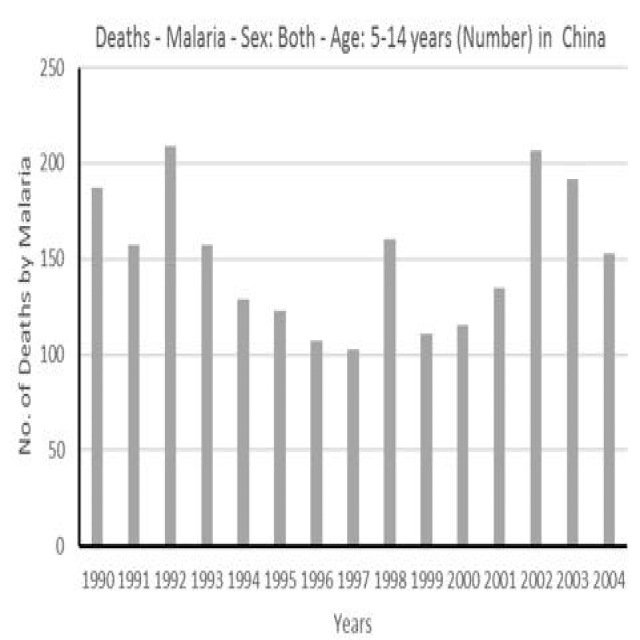

In [16]:
Image.open(fp=matched_image_path[0])

✅ Image loaded: (640, 640, 3)


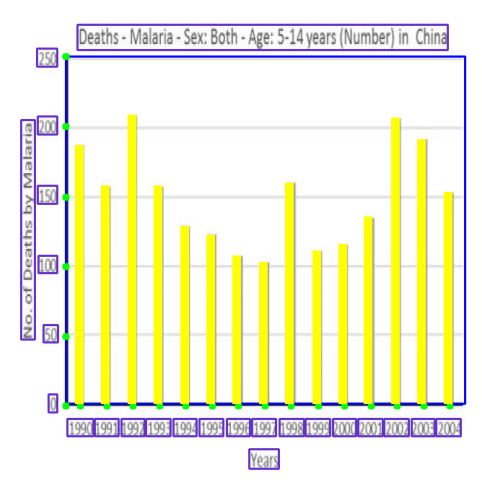

In [17]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path=matched_image_path[0])

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [18]:
# dot
search_string = "0cfa6023c813"
matched_image_path = [file for file in image_files if search_string in file]

print(matched_image_path)

# corresponding annotation file path
matched_annotation_path = [file for file in annotations_files if search_string in file]

print(matched_annotation_path)

['../../../data/image_resize/images/0cfa6023c813.jpg']
['../../../data/image_resize/annotations/0cfa6023c813.json']


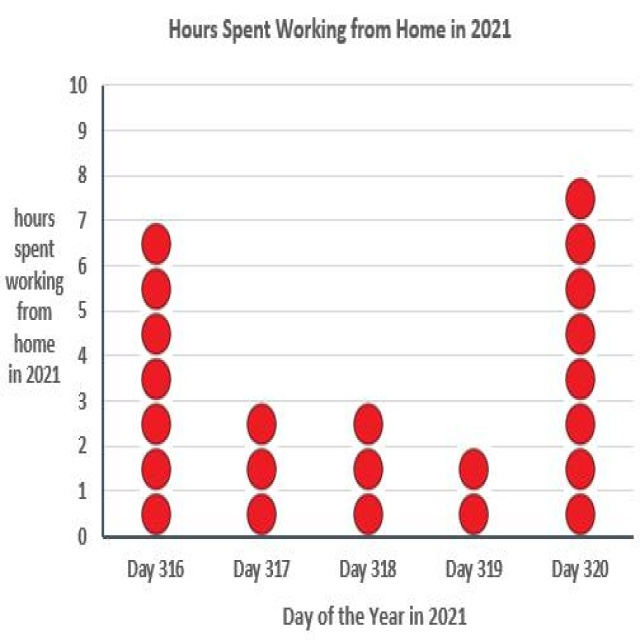

In [19]:
Image.open(fp=matched_image_path[0])

✅ Image loaded: (640, 640, 3)


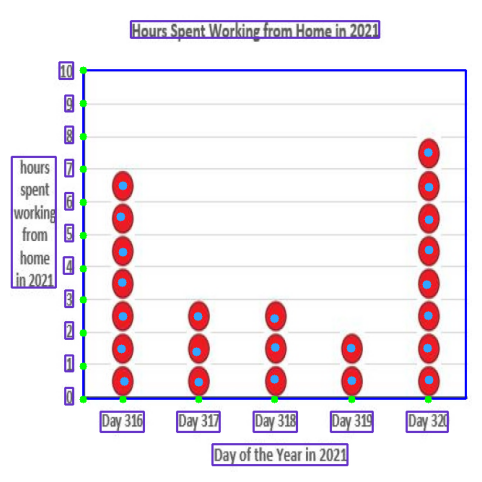

In [20]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path=matched_image_path[0])

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [21]:
# horizontal bar
search_string = "1bd8fa4655f0"
matched_image_path = [file for file in image_files if search_string in file]

print(matched_image_path)

# corresponding annotation file path
matched_annotation_path = [file for file in annotations_files if search_string in file]

print(matched_annotation_path)

['../../../data/image_resize/images/1bd8fa4655f0.jpg']
['../../../data/image_resize/annotations/1bd8fa4655f0.json']


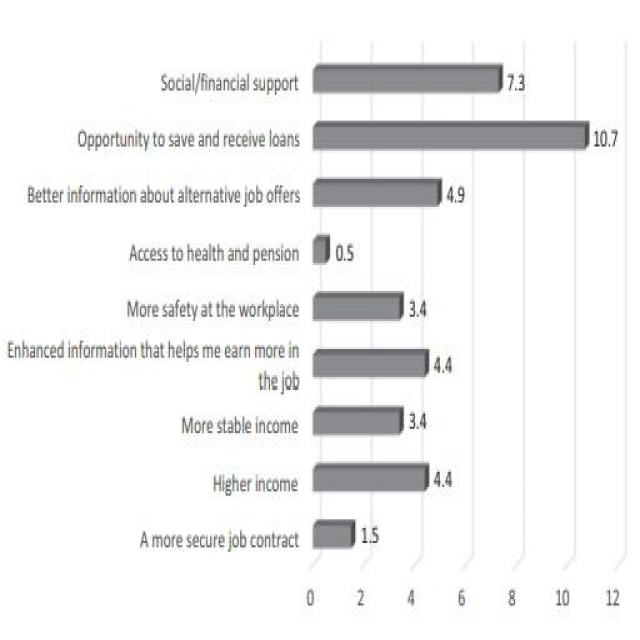

In [22]:
Image.open(fp=matched_image_path[0])

✅ Image loaded: (640, 640, 3)


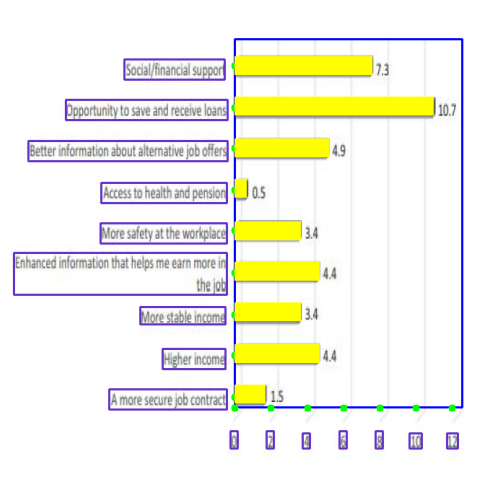

In [23]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path=matched_image_path[0])

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()